## What is Phishing?
#### Phishing is a scam where attackers "fish" for your private info using fake links or messages that look real.
#### Phishing is a type of cyber attack where attackers trick people into revealing sensitive information like passwords, credit card numbers, or personal data by pretending to be a trustworthy source — usually through fake websites, emails, or messages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("phishing_dataset.csv")

In [3]:
df.head()

,NumDots,UrlLength,NumDash,AtSymbol,IpAddress,HttpsInHostname,PathLevel,PathLength,NumNumericChars,Phishing
0,6,232,4,0,0,0,8,125,58,1
1,5,88,2,0,0,0,4,66,1,1
2,7,184,1,0,0,0,11,161,47,1
3,6,67,0,0,0,0,2,42,0,1
4,1,123,1,0,0,0,7,60,21,1


In [4]:
df.sample(5)

,NumDots,UrlLength,NumDash,AtSymbol,IpAddress,HttpsInHostname,PathLevel,PathLength,NumNumericChars,Phishing
38184,9,64,1,0,0,0,1,11,0,1
350384,1,60,3,0,0,0,3,37,3,0
439280,1,68,6,0,0,0,4,51,6,0
121691,1,38,0,0,0,0,2,21,1,1
354132,1,19,0,0,0,0,1,1,0,0


In [5]:
df.isnull().sum()

NumDots            0
UrlLength          0
NumDash            0
AtSymbol           0
IpAddress          0
HttpsInHostname    0
PathLevel          0
PathLength         0
NumNumericChars    0
Phishing           0
dtype: int64

In [6]:
df.dtypes

NumDots            int64
UrlLength          int64
NumDash            int64
AtSymbol           int64
IpAddress          int64
HttpsInHostname    int64
PathLevel          int64
PathLength         int64
NumNumericChars    int64
Phishing           int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549327 entries, 0 to 549326
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   NumDots          549327 non-null  int64
 1   UrlLength        549327 non-null  int64
 2   NumDash          549327 non-null  int64
 3   AtSymbol         549327 non-null  int64
 4   IpAddress        549327 non-null  int64
 5   HttpsInHostname  549327 non-null  int64
 6   PathLevel        549327 non-null  int64
 7   PathLength       549327 non-null  int64
 8   NumNumericChars  549327 non-null  int64
 9   Phishing         549327 non-null  int64
dtypes: int64(10)
memory usage: 41.9 MB


In [8]:
df.describe()

,NumDots,UrlLength,NumDash,AtSymbol,IpAddress,HttpsInHostname,PathLevel,PathLength,NumNumericChars,Phishing
count,549327.000000,549327.000000,549327.000000,549327.000000,549327.000000,549327.000000,549327.000000,549327.000000,549327.000000,549327.000000
mean,2.062360,57.731033,1.126473,0.003715,0.014241,0.000073,2.386897,26.315113,4.769298,0.284748
std,1.514627,44.407518,2.424380,0.060841,0.118483,0.008533,1.513651,24.099233,11.572937,0.451295
min,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,36.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,0.000000,0.000000
50%,2.000000,47.000000,0.000000,0.000000,0.000000,0.000000,2.000000,20.000000,1.000000,0.000000
75%,2.000000,66.000000,1.000000,0.000000,0.000000,0.000000,3.000000,36.000000,6.000000,1.000000
max,37.000000,2314.000000,42.000000,1.000000,1.000000,1.000000,34.000000,2156.000000,545.000000,1.000000


In [9]:
df.shape

(549327, 10)

In [10]:
df.info()
df['Phishing'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549327 entries, 0 to 549326
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   NumDots          549327 non-null  int64
 1   UrlLength        549327 non-null  int64
 2   NumDash          549327 non-null  int64
 3   AtSymbol         549327 non-null  int64
 4   IpAddress        549327 non-null  int64
 5   HttpsInHostname  549327 non-null  int64
 6   PathLevel        549327 non-null  int64
 7   PathLength       549327 non-null  int64
 8   NumNumericChars  549327 non-null  int64
 9   Phishing         549327 non-null  int64
dtypes: int64(10)
memory usage: 41.9 MB


Phishing
0    392907
1    156420
Name: count, dtype: int64

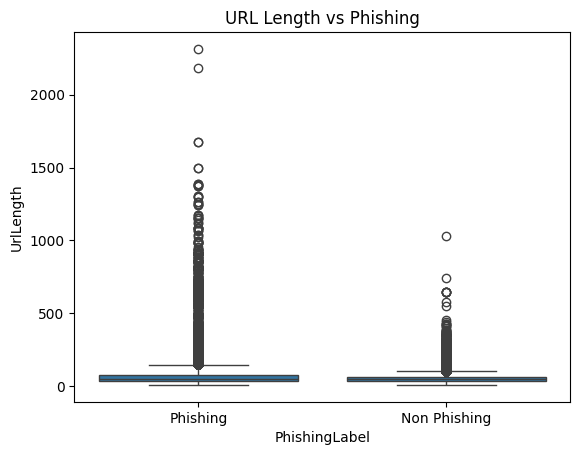

In [11]:
df['PhishingLabel'] = df['Phishing'].map({0: "Non Phishing", 1: "Phishing"})

sns.boxplot(data=df, x='PhishingLabel', y='UrlLength')
plt.title("URL Length vs Phishing")
plt.show()

In [12]:
x = df.drop(columns=["Phishing", "PhishingLabel"], errors='ignore')  
y = df["Phishing"]  

In [13]:
min_range = df["UrlLength"].mean() - (3*df["UrlLength"].std())
max_range = df["UrlLength"].mean() + (3*df["UrlLength"].std())

In [14]:
min_range,max_range

(np.float64(-75.49152076169446), np.float64(190.9535861617203))

In [15]:
df = df[df["UrlLength"]<=max_range]

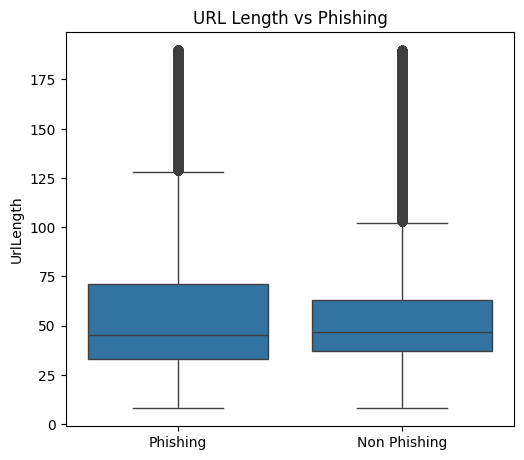

In [16]:
plt.figure(figsize=(5.79, 5.12))
df['PhishingLabel'] = df['Phishing'].map({0: "Non Phishing", 1: "Phishing"})
sns.boxplot(data=df, x='PhishingLabel', y='UrlLength')
plt.title("URL Length vs Phishing")
plt.xlabel("")
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\boxplot.png", dpi=100, transparent=True)
plt.show()


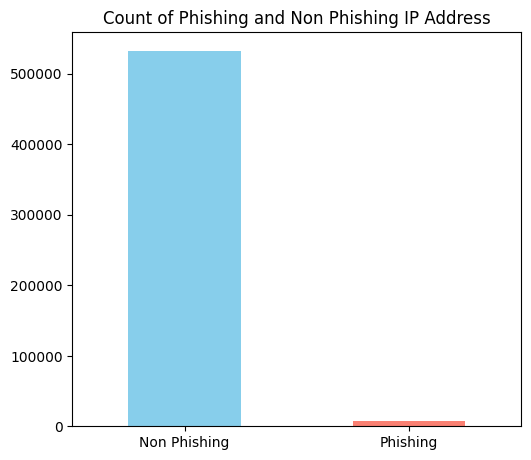

In [17]:
label_map = {0: "Non Phishing", 1: "Phishing"}
counts = df["IpAddress"].map(label_map).value_counts()
plt.figure(figsize=(5.79, 5.12))
plt.title("Count of Phishing and Non Phishing IP Address")
counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks(rotation=0)
plt.xlabel("")
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\count_ip.png", dpi=100, transparent=True)

In [18]:
df.describe()

,NumDots,UrlLength,NumDash,AtSymbol,IpAddress,HttpsInHostname,PathLevel,PathLength,NumNumericChars,Phishing
count,540053.000000,540053.000000,540053.000000,540053.000000,540053.000000,540053.000000,540053.000000,540053.000000,540053.000000,540053.000000
mean,1.985276,53.669238,1.081346,0.003285,0.014443,0.000052,2.365853,25.770130,3.765167,0.273601
std,1.226845,26.688621,2.327848,0.057220,0.119308,0.007200,1.479091,22.345506,6.634715,0.445807
min,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,35.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,0.000000,0.000000
50%,2.000000,47.000000,0.000000,0.000000,0.000000,0.000000,2.000000,20.000000,1.000000,0.000000
75%,2.000000,65.000000,1.000000,0.000000,0.000000,0.000000,3.000000,35.000000,6.000000,1.000000
max,28.000000,190.000000,41.000000,1.000000,1.000000,1.000000,28.000000,189.000000,120.000000,1.000000


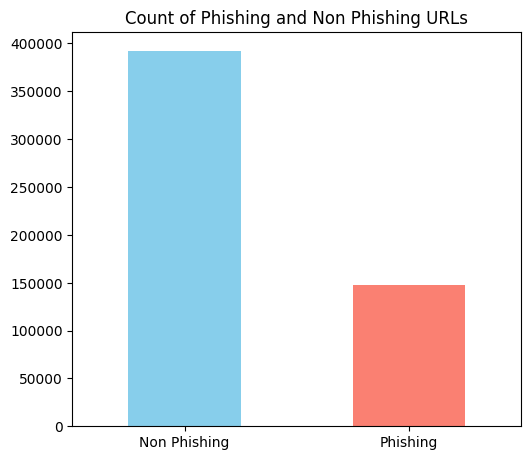

In [19]:
label_map = {0: "Non Phishing", 1: "Phishing"}
counts = df["Phishing"].map(label_map).value_counts()
plt.figure(figsize=(5.79, 5.12))
plt.title("Count of Phishing and Non Phishing URLs")
counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks(rotation=0)
plt.xlabel("")
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\count_plot.png", dpi=100, transparent=True)

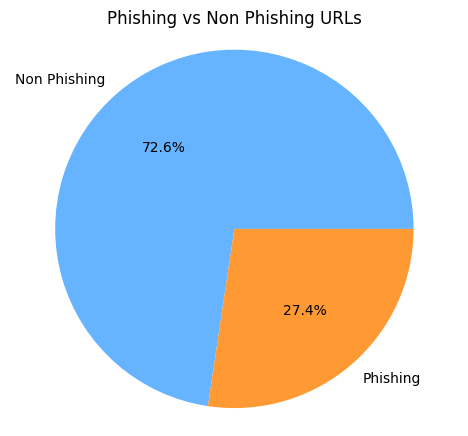

In [20]:
counts = df["Phishing"].value_counts()
label_map = {0: "Non Phishing", 1: "Phishing"}
labels = [label_map[i] for i in counts.index]
sizes = counts.values
plt.figure(figsize=(5.79, 5.12))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#66b3ff', '#ff9933'])
plt.axis('equal')
plt.axis('off')
plt.title("Phishing vs Non Phishing URLs")
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\pie_chart.png", dpi=100, transparent=True)


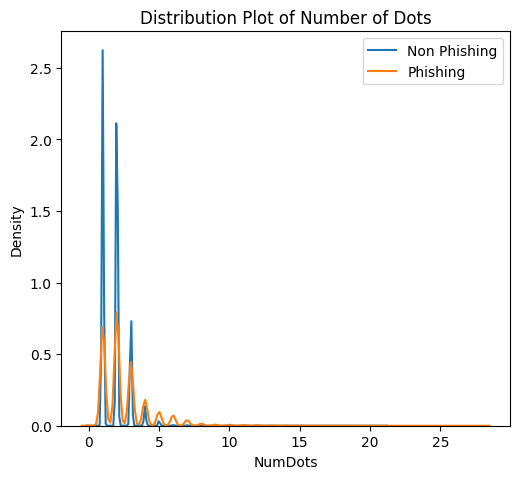

In [21]:
plt.figure(figsize=(5.79, 5.12))
sns.distplot(df[df["Phishing"]==0]['NumDots'],hist=False,label='Non Phishing')
sns.distplot(df[df["Phishing"]==1]['NumDots'],hist = False,label='Phishing')
plt.title("Distribution Plot of Number of Dots")
plt.legend()
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\distplotND.png", dpi=100, transparent=True)

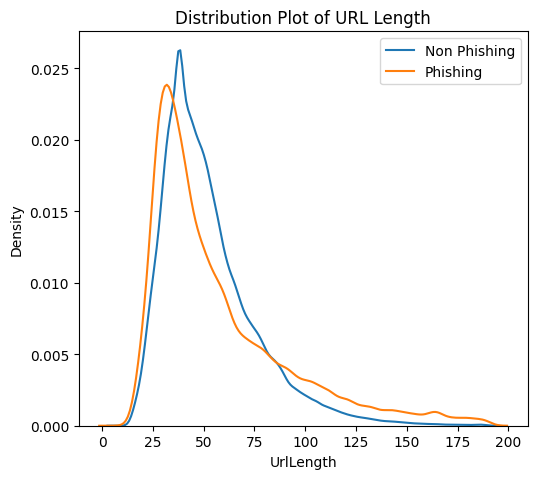

In [22]:
plt.figure(figsize=(5.79, 5.12))
sns.distplot(df[df["Phishing"]==0]['UrlLength'],hist=False,label='Non Phishing')
sns.distplot(df[df["Phishing"]==1]['UrlLength'],hist = False,label='Phishing')
plt.title("Distribution Plot of URL Length")
plt.legend()
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\distplot.png", dpi=100, transparent=True)

In [23]:
# x = df.drop(columns=["Phishing"],axis=1)
# y = df["Phishing"]
x = df.drop(["Phishing", "PhishingLabel"],axis=1)
y = df["Phishing"]

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [25]:
from imblearn.under_sampling import RandomUnderSampler

In [26]:
rus = RandomUnderSampler(random_state=10)
x, y = rus.fit_resample(x, y)

In [27]:
x.shape,y.shape

((295518, 9), (295518,))

In [28]:
x

,NumDots,UrlLength,NumDash,AtSymbol,IpAddress,HttpsInHostname,PathLevel,PathLength,NumNumericChars
54839,2,32,0,0,0,0,2,11,0
438953,2,40,0,0,0,0,1,15,0
232062,2,93,8,0,0,0,5,72,8
49164,2,45,0,0,0,0,3,21,0
236124,1,37,1,0,0,0,1,1,2
...,...,...,...,...,...,...,...,...,...
549322,3,22,0,0,1,0,1,1,11
549323,1,25,1,0,0,0,1,1,0
549324,1,24,1,0,0,0,1,1,0
549325,1,25,1,0,0,0,1,1,0


In [29]:
y

54839     0
438953    0
232062    0
49164     0
236124    0
         ..
549322    1
549323    1
549324    1
549325    1
549326    1
Name: Phishing, Length: 295518, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
print(x_train.dtypes)

NumDots            int64
UrlLength          int64
NumDash            int64
AtSymbol           int64
IpAddress          int64
HttpsInHostname    int64
PathLevel          int64
PathLength         int64
NumNumericChars    int64
dtype: object


In [34]:
print(y_train.value_counts())

Phishing
0    118276
1    118138
Name: count, dtype: int64


In [35]:
print(y_train.unique())

[0 1]


In [36]:
dt = DecisionTreeClassifier(random_state=42,max_depth=15, min_samples_split=15)
dt.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=15, min_samples_split=15, random_state=42)

In [37]:
y_pred = dt.predict(x_test)

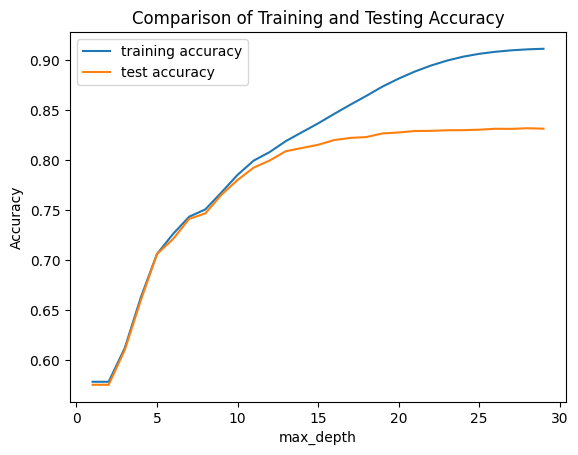

In [38]:
training_accuracy = []
test_accuracy = []
depth = range(1,30)
for n in depth:
    tree_test = DecisionTreeClassifier(max_depth=n)
    tree_test.fit(x_train, y_train)
    training_accuracy.append(tree_test.score(x_train, y_train))
    test_accuracy.append(tree_test.score(x_test, y_test))
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("max_depth")
plt.legend();
plt.title("Comparison of Training and Testing Accuracy")
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\training vs testing.png", dpi=100, transparent=True)

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(y_pred,y_test)*100

81.38366269626421

In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
print("Confusion Matrix: ",confusion_matrix(y_pred,y_test))

Confusion Matrix:  [[24779  6299]
 [ 4704 23322]]


In [43]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [44]:
print("Precision Score: ",precision_score(y_pred,y_test)*100)
print("Recall Score: ",recall_score(y_pred,y_test)*100)
print("F1 Score: ",f1_score(y_pred,y_test)*100)

Precision Score:  78.73468147597988
Recall Score:  83.21558552772426
F1 Score:  80.91314378892224


In [45]:
import pickle
pickle.dump(dt,open('Decision_Tree_Model.pkl','wb'))
pickle.dump(y_test,open('y_test.pkl','wb'))
pickle.dump(y_pred,open('y_pred.pkl','wb'))

In [46]:
import re
from urllib.parse import urlparse

def extract_features(url):
    parsed = urlparse(url)
    hostname = parsed.hostname or ""
    path = parsed.path

    features = [
        url.count('.'),                           # NumDots
        len(url),                                 # UrlLength
        url.count('-'),                           # NumDash
        1 if '@' in url else 0,                   # AtSymbol
        1 if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", hostname) else 0,  # IpAddress
        1 if 'https' in hostname else 0,          # HttpsInHostname
        path.count('/'),                          # PathLevel
        len(path),                                # PathLength
        len(re.findall(r'\d', url))               # NumNumericChars
    ]
    return features

In [47]:
url = "https://www.google.com/"
features = extract_features(url)
print(features)


# url = "https://www.google.com"

# features = extract_features(url)
# features = np.array(features).reshape(1, -1)

# prediction = dt.predict(features)

# if prediction[0] == 0:
#     print("Website is Not Safe")
# else:
#     print("Website is Safe")

[2, 23, 0, 0, 0, 0, 1, 1, 0]


In [48]:
url = "https://www.google.com"

features = extract_features(url)
print("Features:", features)

prediction = dt.predict(np.array(features).reshape(1, -1))
print("Prediction:", prediction)

Features: [2, 22, 0, 0, 0, 0, 0, 0, 0]
Prediction: [1]


In [49]:
result = dt.predict([features])

In [52]:
if(result == 1):
      print("🚨 Website is Not Safe")
else:
    print("✅ Website is Safe")

🚨 Website is Not Safe


# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For training set
ConfusionMatrixDisplay.from_estimator(dt, x_train, y_train, cmap='Blues')
plt.title("Confusion Matrix - Train Set")
plt.show()

# For test set
ConfusionMatrixDisplay.from_estimator(dt, x_test, y_test, cmap='Oranges')
plt.title("Confusion Matrix - Test Set")
plt.show()


In [51]:
plt.figure(figsize=(3,4))
ConfusionMatrixDisplay.from_estimator(dt, x_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig(r"C:\Users\nisha\OneDrive\Desktop\Phishing-URL-Detection-Using-ML\static\confusion_matrix.png", dpi=100, transparent=True)
plt.show()

NameError: name 'ConfusionMatrixDisplay' is not defined

<Figure size 300x400 with 0 Axes>